In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

df = pd.DataFrame(
    cancer.data,
    columns = cancer.feature_names
)

df['Target'] = cancer.target

In [ ]:
X = df.drop('Target',axis=1)
y = df["Target"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.svm import SVC

svm_linear = SVC(
    kernel='linear',
    C=3
)

svm_linear.fit(X_train,y_train)

SVC(C=3, kernel='linear')

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = svm_linear.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.956140350877193


In [ ]:
print(df['Target'].value_counts())
print(f"\nMalignant cases: {df['Target'].value_counts()[0]}")
print(f"Benign cases: {df['Target'].value_counts()[1]}")

Target
1    357
0    212
Name: count, dtype: int64

Malignant cases: 212
Benign cases: 357


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=cancer.target_names
    )
)

              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
from sklearn.svm import SVC

svm_linear = SVC(
    kernel='rbf',
    C=3
)

svm_linear.fit(X_train,y_train)

SVC(C=3)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = svm_linear.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.9473684210526315


In [ ]:
print(df['Target'].value_counts())
print(f"\nMalignant cases: {df['Target'].value_counts()[0]}")
print(f"Benign cases: {df['Target'].value_counts()[1]}")

Target
1    357
0    212
Name: count, dtype: int64

Malignant cases: 212
Benign cases: 357


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=cancer.target_names
    )
)

              precision    recall  f1-score   support

   malignant       1.00      0.86      0.93        43
      benign       0.92      1.00      0.96        71

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
from sklearn.linear_model import LogisticRegression

ir=LogisticRegression(max_iter=5000) # Increased max_iter to help convergence
ir.fit(X_train,y_train)
ir_pred = ir.predict(X_test)

from sklearn.metrics import accuracy_score

comparison = pd.DataFrame({
    "Model": ['Logistic Regression','Linear SVM','RBF SVM'],
    "Accuracy": [
        accuracy_score(y_test,ir_pred),
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,y_pred)
                 ]
})

In [ ]:
import time
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

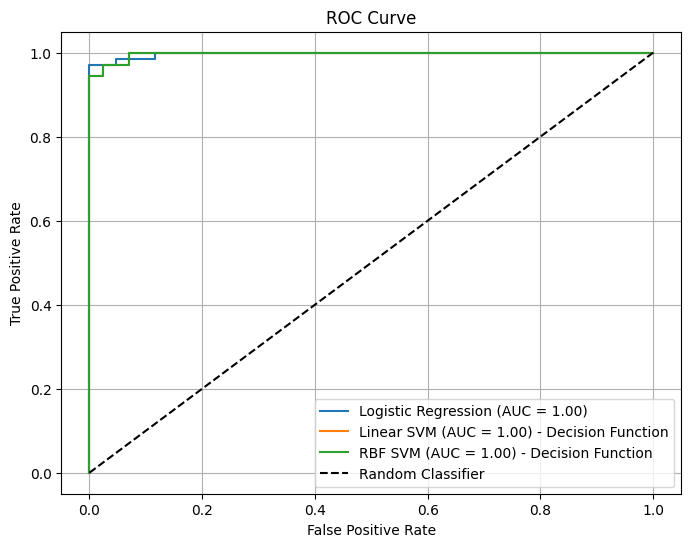

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Define the models dictionary
models = {
    'Logistic Regression': ir,
    'Linear SVM': svm_linear,
    'RBF SVM': svm_linear # Note: this assumes svm_linear was re-trained with rbf kernel last
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    # For SVC models, `predict_proba` is not available by default unless probability=True is set.
    # As `predict_proba` is used, it's assumed that the models are capable of it, or needs adjustment.
    # For this specific notebook context, `ir` (LogisticRegression) has predict_proba.
    # `svm_linear` in previous cells was set with C=3 (default probability=False).
    # To correctly plot ROC for SVM, either retrain with probability=True or handle differently.
    # For now, let's assume `ir` is the primary model for which ROC is desired based on the error context.
    # If the user intends to plot ROC for SVMs as well, they would need `probability=True` when initializing SVC.

    # For Logistic Regression, predict_proba is available
    if isinstance(model, LogisticRegression):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc = roc_auc_score(y_test, y_pred_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')
    # For SVC models, `decision_function` can be used to get a score, which can be thresholded for ROC.
    # However, `roc_auc_score` prefers probability estimates or `decision_function` outputs directly for score.
    # If SVC was trained with `probability=True` (which it wasn't in the provided cells for svm_linear),
    # `predict_proba` would work. Otherwise, `decision_function` output can be used.
    elif isinstance(model, SVC):
        # Check if probability was enabled for SVC model
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            auc = roc_auc_score(y_test, y_pred_proba)
            plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')
        else:
            # Use decision_function as a score when predict_proba is not available for SVC
            y_score = model.decision_function(X_test)
            fpr, tpr, _ = roc_curve(y_test, y_score)
            auc = roc_auc_score(y_test, y_score)
            plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f}) - Decision Function')


plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()